This is a jupyter notebook to visualize the trained GRNNs in the form of a parity plot (like Figure 2a in T. Kircher, F.A. Döppel, M. Votsmeier, Chem. Eng. J. (2024) 149863, http://dx.doi.org/10.1016/j.cej.2024.149863.)

In [1]:
import numpy as np
import torch
import copy
import matplotlib.pyplot as plt

from GlobalReactionNeuralNetwork.chem_struct import ChemicalReactions
from GlobalReactionNeuralNetwork.model import GRNN
from GlobalReactionNeuralNetwork.load_data import Dataset
from GlobalReactionNeuralNetwork.helpers import RMS_RelativeError, RelativeError, check_accuracy

torch.set_default_dtype(torch.double)

N_TRAIN_SAMPLES = 1000
N_HIDDEN = 50
N_LAYERS = 1

Load the pre-trained model and the data

In [ ]:
train = Dataset('train', n_data=N_TRAIN_SAMPLES)
validation = Dataset('validation', train.data_min, train.data_max)
test = Dataset('test', train.data_min, train.data_max)
rel_err = RelativeError()

reactions_dict = {
        0: "H2 + 1/2 O2 <=> H2O",
        1: "CO + 1/2 O2 <=> CO2",
        2: "H2O + CO <=> H2 + CO2"
    }

symbolic_species_variables = {
    'H2': 0,
    'O2': 1,
    'H2O': 2,
    'CO': 3,
    'CO2': 4
}

# Load chemical structure data
chem_struct = ChemicalReactions(
    reactions_dict=reactions_dict,
    symbolic_species_variables=symbolic_species_variables,
    MStoic_path='data/MStoic.csv',
    TD_coeffs_path='data/TD_coeffs.csv'
)

# Initialize GRNN model
n_input = train.x.shape[1]
n_global_reactions = chem_struct.MStoic.shape[0]
model = GRNN(
    input_size=n_input,
    hidden_size=N_HIDDEN,
    output_size=n_global_reactions,
    num_layers=N_LAYERS,
    data_min=train.data_min,
    data_max=train.data_max,
    MStoic=chem_struct.MStoic,
    TD_coeffs=chem_struct.TD_coeffs,
    R=chem_struct.R,
    p_standard=chem_struct.p_standard
)

# Load the pre-trained model
model.load_state_dict(torch.load('data/model.pth', weights_only=True))

Train relative error: 0.195 %
Validation relative error: 0.361 %
Test relative error: 0.343 %


(1e-25, 1000000.0)

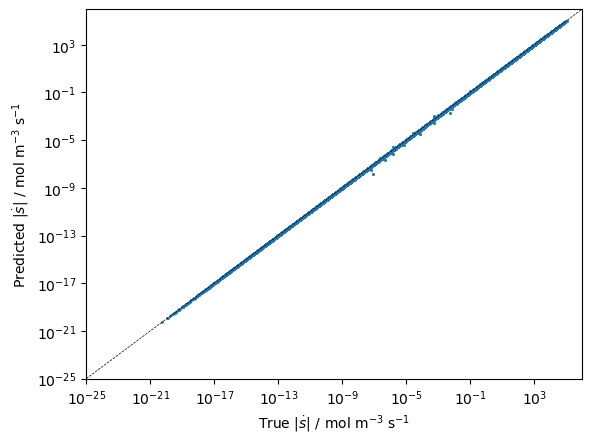

In [3]:
pred_train = model(train.x)
rel_err_train = rel_err(pred_train, train.y)
print(f"Train relative error: {rel_err_train:.3f} %")

pred_val = model(validation.x)
rel_err_val = rel_err(pred_val, validation.y)
print(f"Validation relative error: {rel_err_val:.3f} %") 

pred_test = model(test.x)
rel_err_test = rel_err(pred_test, test.y)
print(f"Test relative error: {rel_err_test:.3f} %")

#parity plot
fig, ax = plt.subplots()
ax.scatter(np.abs(test.y.detach().numpy()), np.abs(pred_test.detach().numpy()), s=1)
ax.plot([1e-25, 1e6], [1e-25, 1e6], 'k--', lw=0.5)
ax.set_xlabel(r'True $|\dot{s}|$ / mol m$^{-3}$ s$^{-1}$')
ax.set_ylabel('Predicted $|\dot{s}|$ / mol m$^{-3}$ s$^{-1}$')
ax.set_xscale('log', base=10)
ax.set_yscale('log', base=10)

ax.set_xlim([1e-25, 1e6])
ax.set_ylim([1e-25, 1e6])